In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np

import shap

import matplotlib.pyplot as plt

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from features import engineer_features, EngineeredFeatures

In [2]:
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)

In [3]:
RANDOM = 42

In [4]:
train_tx = pd.read_csv("dataset/train_transactions.csv", engine="python")
train_users = pd.read_csv("dataset/train_users.csv", index_col='id_user')

test_tx = pd.read_csv('dataset/test_transactions.csv')
test_users = pd.read_csv('dataset/test_users.csv', index_col='id_user')

In [5]:
# train_users = train_users.iloc[:1000]
# train_tx = train_tx[train_tx['id_user'].isin(train_users.index)]

# test_users = test_users.iloc[:1000]
# test_tx = test_tx[test_tx['id_user'].isin(test_users.index)]

In [6]:
test_users['is_fraud'] = False
train_users['split'] = pd.read_csv('dataset/splits.csv', index_col='id_user')
test_users['split'] = 2
users = pd.concat((train_users, test_users), axis=0)

tx = pd.concat((train_tx, test_tx), axis=0, ignore_index=True)

In [7]:
features = engineer_features(tx, users)
users, tx = features.users, features.tx
user_features = features.user_features
tx_features = features.tx_features

In [8]:
users

,timestamp_reg,email,gender,reg_country,traffic_type,is_fraud,split,is_male,timestamp_reg_dt,median_tx_time_gap,...,rate_error_group_expired error,rate_error_group_fraud,rate_error_group_insufficient funds error,rate_error_group_invalid data,rate_error_group_issuer decline,rate_error_group_limit exceeded error,rate_error_group_merchant problem,rate_error_group_technical issue,rate_error_group_token error,rate_error_group_user decline
id_user,,,,,,,,,,,,,,,,,,,,,
15383249,2025-07-16 19:01:23.868869+00:00,larsjohansson@gmail.com,male,Sweden,cpa,0,1,True,2025-07-16 19:01:23.868869+00:00,0.742639,...,0.000000,0.016791,0.022388,0.0,0.022388,0.0,0.0,0.0,0.0,0.0
9458117,2025-05-04 19:30:02.902877+00:00,evamark@yahoo.com,male,Romania,cpa,0,0,True,2025-05-04 19:30:02.902877+00:00,47.027917,...,0.000000,0.019231,0.019231,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
21312302,2025-09-07 18:24:51+00:00,stmark86@gmail.com,male,Austria,ppc,0,0,True,2025-09-07 18:24:51+00:00,0.293611,...,0.000000,0.285714,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
61828,2025-01-01 17:33:08.026088+00:00,robertwalker@gmail.com,male,Portugal,organic,1,1,True,2025-01-01 17:33:08.026088+00:00,0.038501,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
13164211,2025-06-21 18:27:03.420098+00:00,sarah.miller@gmail.com,female,Belgium,organic,0,0,False,2025-06-21 18:27:03.420098+00:00,25.615278,...,0.039216,0.000000,0.225490,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28612742,2025-11-06 23:43:13+00:00,robert11281977@gmail.com,female,United States,ppc,0,2,False,2025-11-06 23:43:13+00:00,NaN,...,0.000000,0.000000,1.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2452157,2025-02-01 08:46:57.119002+00:00,oliviamiller2@gmail.com,male,United States,cpa,0,2,True,2025-02-01 08:46:57.119002+00:00,NaN,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
8568374,2025-04-23 04:18:23.447816+00:00,sjmiller54@yahoo.com,male,United States,ppc,0,2,True,2025-04-23 04:18:23.447816+00:00,NaN,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0


In [9]:
Xt = tx[tx_features].copy()
cat_features = [col for col in Xt.columns if Xt[col].dtype == "object"]
Xt[cat_features] = Xt[cat_features].fillna("unknown")
yt = tx["is_fraud"]

In [10]:
train_mask, eval_mask = tx["id_user"].isin(users[users['split'] == 0].index), tx["id_user"].isin(users[users['split'] == 1].index)

Xt_train = Xt[train_mask]
Xt_eval = Xt[eval_mask]

yt_train = yt[train_mask]
yt_eval = yt[eval_mask]

In [11]:
model_tx = CatBoostClassifier(
    n_estimators=200,
    depth=8,
    learning_rate=0.1,
    eval_metric="AUC",
    verbose=True,
    random_state=RANDOM,
    cat_features=cat_features,
)
model_tx.fit(Xt_train, yt_train, eval_set=(Xt_eval, yt_eval))

0:	test: 0.7260129	best: 0.7260129 (0)	total: 994ms	remaining: 3m 17s
1:	test: 0.7233922	best: 0.7260129 (0)	total: 1.83s	remaining: 3m
2:	test: 0.7311857	best: 0.7311857 (2)	total: 2.56s	remaining: 2m 48s
3:	test: 0.7374637	best: 0.7374637 (3)	total: 3.28s	remaining: 2m 40s
4:	test: 0.7360839	best: 0.7374637 (3)	total: 4.08s	remaining: 2m 39s
5:	test: 0.7399452	best: 0.7399452 (5)	total: 4.85s	remaining: 2m 36s
6:	test: 0.7403573	best: 0.7403573 (6)	total: 5.64s	remaining: 2m 35s
7:	test: 0.7421216	best: 0.7421216 (7)	total: 6.45s	remaining: 2m 34s
8:	test: 0.7450523	best: 0.7450523 (8)	total: 7.2s	remaining: 2m 32s
9:	test: 0.7535167	best: 0.7535167 (9)	total: 7.92s	remaining: 2m 30s
10:	test: 0.7592686	best: 0.7592686 (10)	total: 8.58s	remaining: 2m 27s
11:	test: 0.7639591	best: 0.7639591 (11)	total: 9.3s	remaining: 2m 25s
12:	test: 0.7639345	best: 0.7639591 (11)	total: 10.1s	remaining: 2m 24s
13:	test: 0.7639442	best: 0.7639591 (11)	total: 10.9s	remaining: 2m 24s
14:	test: 0.767362

CatBoostClassifier(cat_features=['payment_country', 'card_country', 'card_type', 'card_brand', 'currency', 'error_group', 'transaction_type', 'card_holder_gender', 'reg_country', 'traffic_type'], depth=8, eval_metric='AUC', learning_rate=0.1, n_estimators=200, random_state=42, verbose=True)

ROC AUC: 0.7676


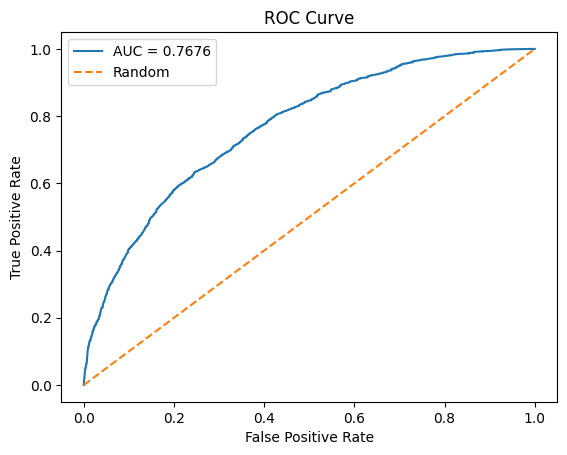

In [12]:
probs = model_tx.predict_proba(Xt_eval)[:, 1]

roc_auc = roc_auc_score(yt_eval, probs)
print(f"ROC AUC: {roc_auc:.4f}")
fpr, tpr, thresholds = roc_curve(yt_eval, probs)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

In [13]:
Xu = users[user_features].copy()
cat_features = [col for col in Xu.columns if Xu[col].dtype == "object"]
Xu[cat_features] = Xu[cat_features].fillna("unknown")
yu = users["is_fraud"]

In [14]:
tx["probs2"] = model_tx.predict_proba(Xt)[:, 1]
Xu_probs = tx.groupby("id_user")["probs2"].agg(["mean", "max"])
Xu['mean_probs2'] = Xu_probs['mean']
Xu['max_probs2'] = Xu_probs['max']

In [15]:
Xu_train, Xu_eval = Xu[users['split'] == 0], Xu[users['split'] == 1]
yu_train, yu_eval = yu[users['split'] == 0], yu[users['split'] == 1]

In [16]:
model_user = CatBoostClassifier(
    n_estimators=500,
    depth=10,
    learning_rate=0.1,
    eval_metric="AUC",
    random_state=RANDOM,
    cat_features=cat_features,
)
model_user.fit(Xu_train, yu_train, eval_set=(Xu_eval, yu_eval))

0:	test: 0.8999994	best: 0.8999994 (0)	total: 148ms	remaining: 1m 13s
1:	test: 0.9494081	best: 0.9494081 (1)	total: 307ms	remaining: 1m 16s
2:	test: 0.9605827	best: 0.9605827 (2)	total: 448ms	remaining: 1m 14s
3:	test: 0.9741439	best: 0.9741439 (3)	total: 600ms	remaining: 1m 14s
4:	test: 0.9758299	best: 0.9758299 (4)	total: 743ms	remaining: 1m 13s
5:	test: 0.9784083	best: 0.9784083 (5)	total: 891ms	remaining: 1m 13s
6:	test: 0.9816671	best: 0.9816671 (6)	total: 1.04s	remaining: 1m 13s
7:	test: 0.9822045	best: 0.9822045 (7)	total: 1.19s	remaining: 1m 13s
8:	test: 0.9825143	best: 0.9825143 (8)	total: 1.35s	remaining: 1m 13s
9:	test: 0.9837295	best: 0.9837295 (9)	total: 1.52s	remaining: 1m 14s
10:	test: 0.9841638	best: 0.9841638 (10)	total: 1.7s	remaining: 1m 15s
11:	test: 0.9850002	best: 0.9850002 (11)	total: 1.88s	remaining: 1m 16s
12:	test: 0.9858808	best: 0.9858808 (12)	total: 2.07s	remaining: 1m 17s
13:	test: 0.9863904	best: 0.9863904 (13)	total: 2.25s	remaining: 1m 18s
14:	test: 0.9

CatBoostClassifier(cat_features=['email_domain', 'reg_country', 'traffic_type', 'first_tx_error_group'], depth=10, eval_metric='AUC', learning_rate=0.1, n_estimators=500, random_state=42)

ROC AUC: 0.994774
Confusion matrix:
[[75713   481]
 [  473  2409]]
Accuracy: 0.988, F1: 0.835


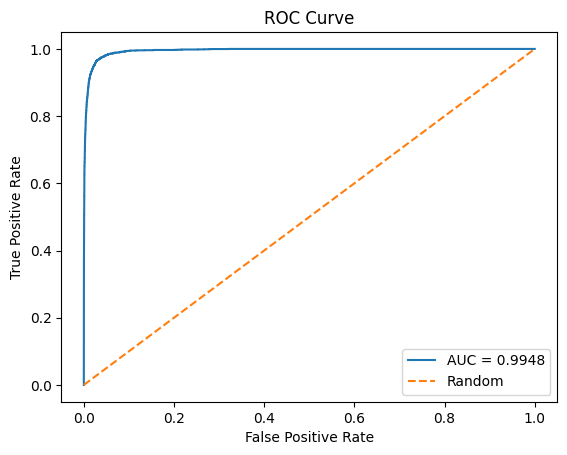

In [20]:
probs = model_user.predict_proba(Xu_eval)[:, 1]

roc_auc = roc_auc_score(yu_eval, probs)
print(f"ROC AUC: {roc_auc:.6f}")
fpr, tpr, thresholds = roc_curve(yu_eval, probs)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1], [0,1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

THRESHOLD = 0.37
preds = (probs > THRESHOLD).astype(int)

cm = confusion_matrix(yu_eval, y_pred=preds)
print('Confusion matrix:')
print(cm)

print(f"Accuracy: {accuracy_score(yu_eval, preds):.3f}, F1: {f1_score(yu_eval, preds):.3f}")

In [21]:
Xu_test = Xu[users['split'] == 2]

probs = model_user.predict_proba(Xu_test)[:, 1]
THRESHOLD = 0.37
preds = (probs > THRESHOLD).astype(int)
preds = pd.Series(preds, index=users[users['split'] == 2].index)

tu = pd.read_csv('dataset/test_users.csv')[['id_user']]
tu['is_fraud'] = tu['id_user'].map(preds)
tu.to_csv('test_users_output.csv', index=False)